
# EDA Completa - Walmart
**Aluno:** Vinícius César Sena Torres  
**RA:** 22409225



## Objetivo
Conduzir uma análise exploratória abrangente para embasar as decisões dos módulos de clusterização e regras associativas, documentando padrões demográficos, comportamentais e estatísticos.


In [12]:

# Estruturo o ambiente exploratório e importo o dataset original.
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats

sns.set_theme(style='whitegrid', palette='deep')

DATA_PATH = Path('..') / 'walmart.csv'
df = pd.read_csv(DATA_PATH)

print(f'Observações: {df.shape[0]} | Variáveis: {df.shape[1]}')
display(df.head())


Observações: 550068 | Variáveis: 10


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [13]:

# Panorama estrutural: tipos, cardinalidade e possíveis duplicatas.
structure = pd.DataFrame({
    'tipo': df.dtypes,
    'cardinalidade': df.nunique(),
    'faltantes': df.isna().sum()
}).sort_values('cardinalidade', ascending=False)
display(structure)
print(f'Linhas totalmente duplicadas: {df.duplicated().sum()}')


,tipo,cardinalidade,faltantes
Purchase,int64,18105,0
User_ID,int64,5891,0
Product_ID,object,3631,0
Occupation,int64,21,0
Product_Category,int64,20,0
Age,object,7,0
Stay_In_Current_City_Years,object,5,0
City_Category,object,3,0
Gender,object,2,0
Marital_Status,int64,2,0


Linhas totalmente duplicadas: 0


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Purchase,550068.0,9263.968713,5023.065394,12.0,5823.0,8047.0,12054.0,16317.0,19336.0,20665.0,23961.0


Coeficiente de assimetria: 0.60


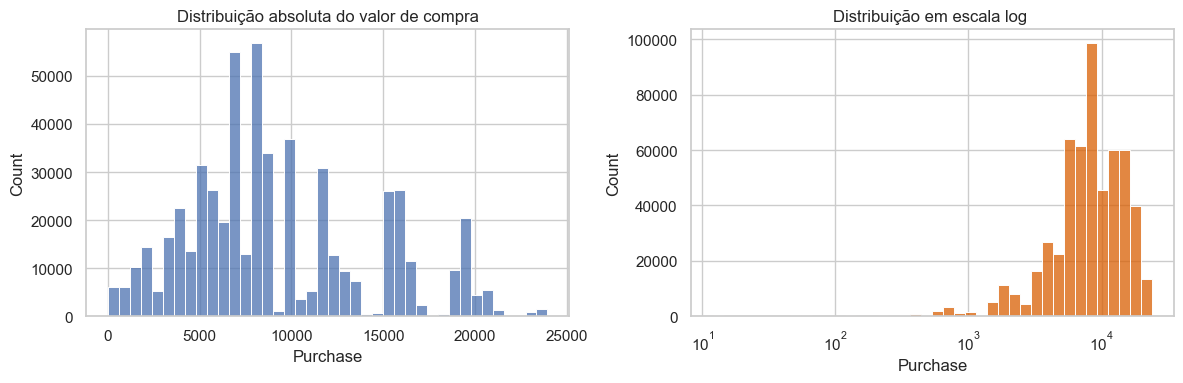

In [14]:

# Distribuição do valor de compra.
purchase_desc = df['Purchase'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])
display(purchase_desc.to_frame().T)
print(f'Coeficiente de assimetria: {stats.skew(df["Purchase"]):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Purchase'], bins=40, ax=axes[0])
axes[0].set_title('Distribuição absoluta do valor de compra')
sns.histplot(df['Purchase'], bins=40, ax=axes[1], log_scale=True, color='#d95f02')
axes[1].set_title('Distribuição em escala log ')
plt.tight_layout()
plt.show()


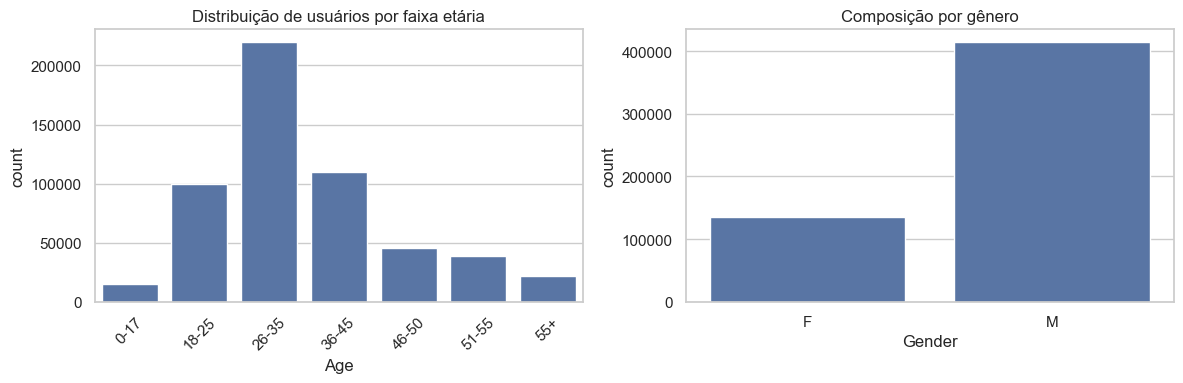

In [15]:

# Composição demográfica dos usuários (idade e gênero).
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Age', order=age_order, ax=axes[0])
axes[0].set_title('Distribuição de usuários por faixa etária')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='Gender', ax=axes[1])
axes[1].set_title('Composição por gênero')
plt.tight_layout()
plt.show()


C:\Users\vinic\AppData\Local\Temp\ipykernel_19984\2219910705.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_ticket, x='Gender', y='Purchase', ax=axes[0], palette='pastel')


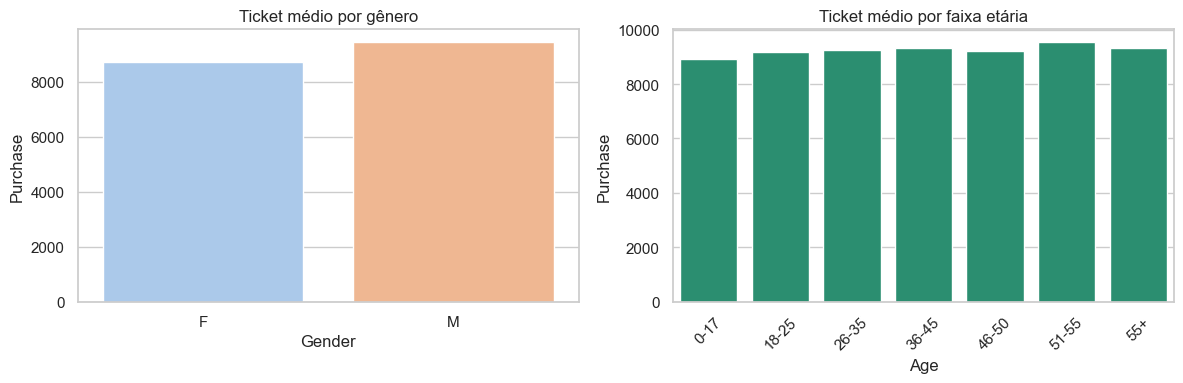

In [16]:

# Ticket médio por gênero e faixa etária para detectar diferenças de consumo.
gender_ticket = df.groupby('Gender')['Purchase'].mean().reset_index()
age_ticket = df.groupby('Age')['Purchase'].mean().reindex(age_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=gender_ticket, x='Gender', y='Purchase', ax=axes[0], palette='pastel')
axes[0].set_title('Ticket médio por gênero')
sns.barplot(data=age_ticket, x='Age', y='Purchase', ax=axes[1], color='#1b9e77')
axes[1].set_title('Ticket médio por faixa etária')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


,Product_Category,freq,participacao
0,5,150933,27.775467
1,1,140378,25.833082
2,8,113925,20.965065
3,11,24287,4.469419
4,2,23864,4.391576
5,6,20466,3.766259
6,3,20213,3.719700
7,4,11753,2.162848
8,16,9828,1.808599
9,15,6290,1.157518


C:\Users\vinic\AppData\Local\Temp\ipykernel_19984\4033329658.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cat, x='Product_Category', y='freq', palette='viridis')


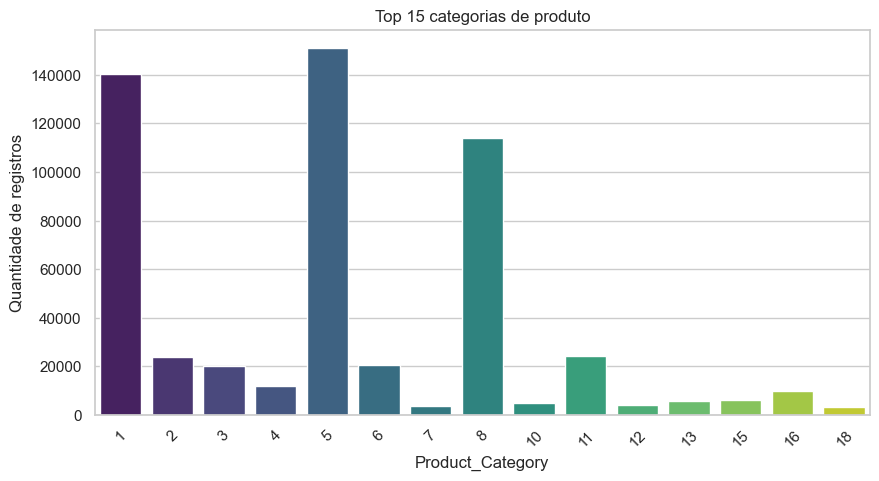

In [17]:

# Preferência por categorias de produto para identificar mix dominante.
top_cat = (
    df['Product_Category']
    .fillna(-1)
    .value_counts()
    .head(15)
    .reset_index(name='freq')
    .rename(columns={'index':'Product_Category'})
)
top_cat['participacao'] = (top_cat['freq'] / top_cat['freq'].sum()) * 100

display(top_cat)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cat, x='Product_Category', y='freq', palette='viridis')
plt.title('Top 15 categorias de produto')
plt.xticks(rotation=45)
plt.ylabel('Quantidade de registros')
plt.show()


,City_Category,count,mean,sum
0,A,147720,8911.939216,1316471661
1,B,231173,9151.300563,2115533605
2,C,171175,9719.920993,1663807476


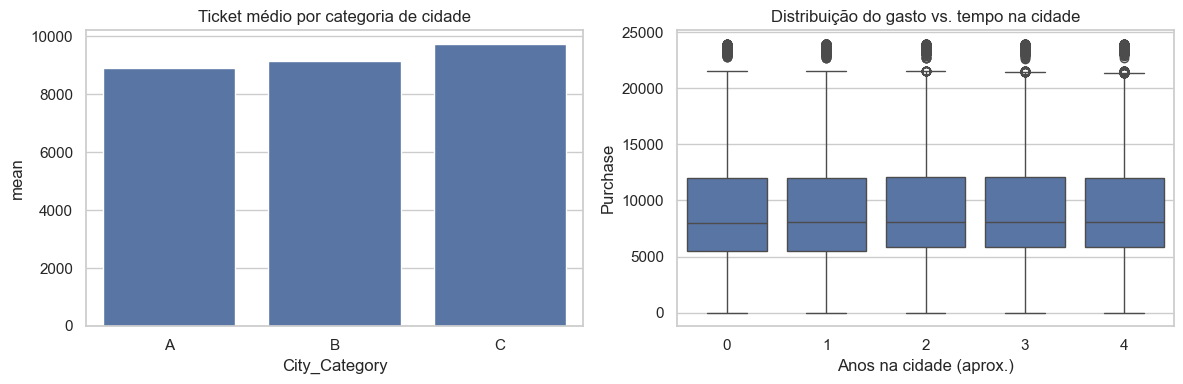

In [18]:

# Desempenho por cidade e tempo de residência para avaliar influência geográfica.
df['Stay_Num'] = df['Stay_In_Current_City_Years'].str.replace('+','', regex=False).astype(int)
city_summary = df.groupby('City_Category')['Purchase'].agg(['count','mean','sum']).reset_index()
display(city_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=city_summary, x='City_Category', y='mean', ax=axes[0])
axes[0].set_title('Ticket médio por categoria de cidade')
sns.boxplot(data=df, x='Stay_Num', y='Purchase', ax=axes[1])
axes[1].set_title('Distribuição do gasto vs. tempo na cidade')
axes[1].set_xlabel('Anos na cidade (aprox.)')
plt.tight_layout()
plt.show()


,User_ID,freq,monetary,ticket_medio,categorias,produtos
count,5.891000e+03,5891.000000,5.891000e+03,5891.000000,5891.000000,5891.000000
mean,1.003025e+06,93.374300,8.650166e+05,9568.839914,9.638771,93.374300
std,1.743379e+03,107.190049,9.436445e+05,1890.087105,3.595397,107.190049
min,1.000001e+06,6.000000,4.668100e+04,2318.733333,1.000000,6.000000
25%,1.001518e+06,26.000000,2.376780e+05,8287.212366,7.000000,26.000000
50%,1.003026e+06,54.000000,5.212130e+05,9386.208333,9.000000,54.000000
75%,1.004532e+06,117.000000,1.119250e+06,10654.633199,12.000000,117.000000
90%,1.005440e+06,225.000000,2.069404e+06,11998.243902,15.000000,225.000000
max,1.006040e+06,1026.000000,1.053691e+07,18577.893617,19.000000,1026.000000


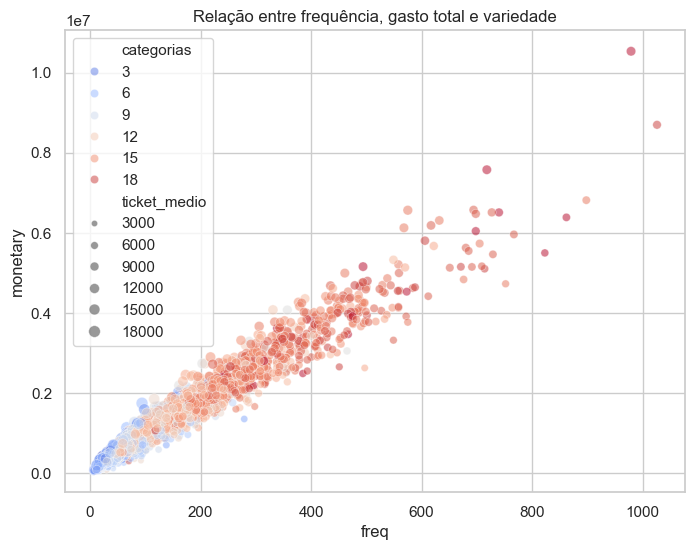

In [19]:

# Métricas agregadas por usuário ajudam a sustentar o módulo de clusterização.
user_metrics = (
    df.groupby('User_ID')
    .agg(
        freq=('Purchase','count'),
        monetary=('Purchase','sum'),
        ticket_medio=('Purchase','mean'),
        categorias=('Product_Category','nunique'),
        produtos=('Product_ID','nunique'),
        cidade=('City_Category','first'),
        idade=('Age','first')
    )
    .reset_index()
)
display(user_metrics.describe(percentiles=[0.25,0.5,0.75,0.9]))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=user_metrics,
    x='freq',
    y='monetary',
    hue='categorias',
    size='ticket_medio',
    alpha=0.5,
    palette='coolwarm'
)
plt.title('Relação entre frequência, gasto total e variedade')
plt.show()


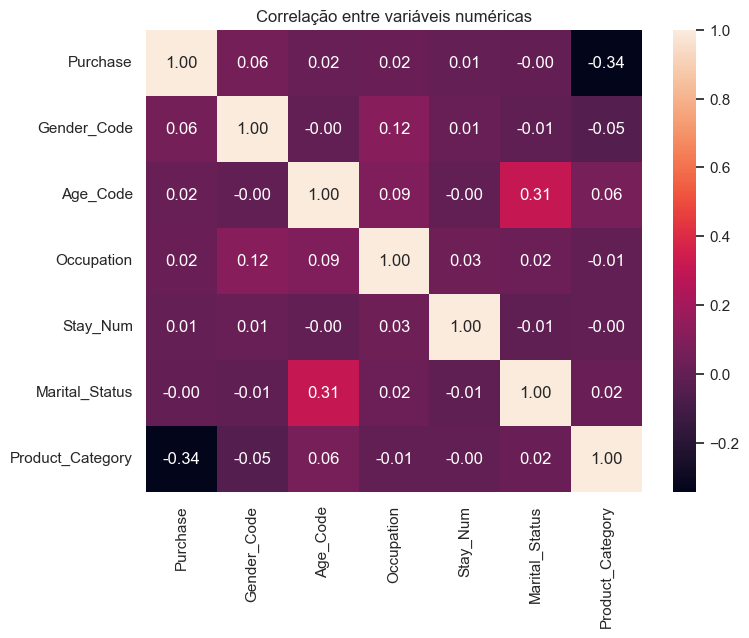

In [20]:

# Matriz de correlação entre variáveis numéricas e codificadas.
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
age_map = {age: idx for idx, age in enumerate(age_order)}

corr_df = df.copy()
corr_df['Product_Category'] = corr_df['Product_Category'].fillna(-1)
corr_df['Gender_Code'] = corr_df['Gender'].map({'F':0,'M':1})
corr_df['Age_Code'] = corr_df['Age'].map(age_map)
corr_df['Stay_Num'] = corr_df['Stay_In_Current_City_Years'].str.replace('+','', regex=False).astype(int)

numeric_cols = ['Purchase','Gender_Code','Age_Code','Occupation','Stay_Num','Marital_Status','Product_Category']
corr_matrix = corr_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='rocket', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.show()


In [21]:

# Registro das principais observações para referência rápida.
insights = [
    f"Ticket médio geral: R${df['Purchase'].mean():,.2f}",
    f"Categorias 5 e 1 representam {df['Product_Category'].value_counts().head(2).sum() / df.shape[0]:.1%} das transações.",
    f"Usuários com mais de 3 anos na cidade apresentam ticket mediano de R${df[df['Stay_Num']>=3]['Purchase'].median():,.2f}.",
    f"O coeficiente de correlação mais alto envolve ocupação e idade codificada ({corr_matrix.loc['Occupation','Age_Code']:.2f})."
]
print('\n'.join(insights))


Ticket médio geral: R$9,263.97
Categorias 5 e 1 representam 53.0% das transações.
Usuários com mais de 3 anos na cidade apresentam ticket mediano de R$8,049.00.
O coeficiente de correlação mais alto envolve ocupação e idade codificada (0.09).
